# SAAM Project — Part II, Sections 3.2 / 3.3 / 3.4: Carbon-Constrained Portfolios
**Group AT** — North America (AMER) / Scope 1+2

### Section 3.2 — $P^{(mv)}_{oos}(0.5)$: Carbon-Constrained Minimum-Variance
$$\\min_{\\alpha_Y}\\; \\alpha_Y'\\Sigma_Y\\alpha_Y \\quad \\text{s.t.} \\quad \\mathbf{c}_Y'\\alpha_Y \\leq 0.5\\times CF_Y^{(mv)},\\quad \\alpha_Y'\\mathbf{1}=1,\\quad \\alpha_{i,Y}\\geq 0$$

### Section 3.3 — $P^{(vw)}_{oos}(0.5)$: Tracking-Error Minimization
$$\\min_{\\alpha_Y}\\;\\sqrt{(\\alpha_Y-\\alpha_Y^{(vw)})'\\Sigma_Y(\\alpha_Y-\\alpha_Y^{(vw)})} \\quad \\text{s.t.} \\quad \\mathbf{c}_Y'\\alpha_Y \\leq 0.5\\times CF_Y^{(vw)},\\quad \\alpha_Y'\\mathbf{1}=1,\\quad \\alpha_{i,Y}\\geq 0$$

**Key formula:** $CF_Y^{(p)} = \\mathbf{c}_Y'\\alpha_Y$ with $c_{i,Y}=E_{i,Y}/Cap_{i,Y}$ is **linear** in $\\alpha$.

**Dependencies:** run `carbon_emissions.ipynb` before this notebook.



## 0. Setup and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
import os
warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────────────────────
Y0                = 2013
Y_END             = 2024
ESTIMATION_WINDOW = 120
RIDGE_LAMBDA      = 1e-8
MIN_COMMON_OBS    = 24
CF_REDUCTION      = 0.50
DATA_DIR          = './cleaned_data/'
CHARTS_DIR        = './Charts/'
os.makedirs(CHARTS_DIR, exist_ok=True)

COLOR_MV   = '#1f4e79'
COLOR_MV05 = '#2980b9'
COLOR_VW   = '#c0392b'
COLOR_TE05 = '#e67e22'

years_alloc = list(range(Y0, Y_END + 1))


# cell, making it unavailable if that cell was skipped during execution.
years_p = years_alloc

print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
required = [
    'returns_monthly.csv', 'co2_total.csv', 'mv_yearly.csv',
    'investment_sets.csv', 'risk_free_rate.csv', 'firm_names.csv',
    'mv_optimal_weights.csv', 'vw_yearend_weights.csv',
    'mv_portfolio_returns.csv', 'vw_portfolio_returns.csv',
    'cf_mv_annual.csv', 'cf_vw_annual.csv',
    'waci_mv_annual.csv', 'waci_vw_annual.csv', 'ci_annual.csv',
]
missing = [f for f in required if not os.path.exists(f'{DATA_DIR}{f}')]
if missing:
    raise FileNotFoundError(f'Missing: {missing}. Run all previous notebooks first.')

returns_m = pd.read_csv(f'{DATA_DIR}returns_monthly.csv', index_col=0, parse_dates=False)
returns_m.columns = pd.to_datetime(returns_m.columns)
dates_ret   = returns_m.columns.tolist()
dec_ret_idx = {d.year: i for i, d in enumerate(dates_ret) if d.month == 12}

co2_total = pd.read_csv(f'{DATA_DIR}co2_total.csv', index_col=0)
co2_total.columns = [int(c) for c in co2_total.columns]

mv_y = pd.read_csv(f'{DATA_DIR}mv_yearly.csv', index_col=0)
mv_y.columns = [int(c) for c in mv_y.columns]

CI = pd.read_csv(f'{DATA_DIR}ci_annual.csv', index_col=0)
CI.columns = [int(c) for c in CI.columns]

inv_df = pd.read_csv(f'{DATA_DIR}investment_sets.csv')
investment_sets = {int(Y): grp['ISIN'].tolist() for Y, grp in inv_df.groupby('Year')}

rf_df   = pd.read_csv(f'{DATA_DIR}risk_free_rate.csv')
rf_dict = {(int(r['year']), int(r['month'])): r['RF_monthly'] for _, r in rf_df.iterrows()}

firm_names = pd.read_csv(f'{DATA_DIR}firm_names.csv', index_col=0).squeeze().to_dict()

mv_wt_df = pd.read_csv(f'{DATA_DIR}mv_optimal_weights.csv')
mv_weights_dict = {
    int(Y): grp.set_index('ISIN')['Weight'] for Y, grp in mv_wt_df.groupby('Year')
}
df_mv_ret = pd.read_csv(f'{DATA_DIR}mv_portfolio_returns.csv', index_col=0, parse_dates=True)
df_vw_ret = pd.read_csv(f'{DATA_DIR}vw_portfolio_returns.csv', index_col=0, parse_dates=True)

def load_annual_series(filename, col):
    s = pd.read_csv(f'{DATA_DIR}{filename}', index_col=0)[col]
    s.index = s.index.astype(int)
    return s.to_dict()

cf_mv   = load_annual_series('cf_mv_annual.csv',   'CF_mv')
cf_vw   = load_annual_series('cf_vw_annual.csv',   'CF_vw')
waci_mv = load_annual_series('waci_mv_annual.csv', 'WACI_mv')
waci_vw = load_annual_series('waci_vw_annual.csv', 'WACI_vw')

print(f'Returns:  {returns_m.shape[0]} firms x {returns_m.shape[1]} months')
print(f'CF(mv) range: {min(cf_mv.values()):.2f} - {max(cf_mv.values()):.2f}')
print(f'CF(vw) range: {min(cf_vw.values()):.2f} - {max(cf_vw.values()):.2f}')

Returns:  589 firms x 313 months
CF(mv) range: 97.32 - 474.01
CF(vw) range: 50.39 - 162.39


## 2. Helper Functions

In [3]:
def estimate_covariance_robust(ret_window, ridge_lambda=1e-8, min_common_obs=24):
    """Identical estimator to min_variance_portfolio.ipynb."""
    N = ret_window.shape[0]
    mu_hat     = ret_window.mean(axis=1).values
    cov_pandas = ret_window.T.cov(min_periods=min_common_obs)
    valid      = (~ret_window.isna()).values.astype(float)
    n_common   = valid @ valid.T
    with np.errstate(divide='ignore', invalid='ignore'):
        adjust = np.where(n_common > 1, (n_common - 1) / n_common, 0.0)
    cov_matrix = cov_pandas.values * adjust
    cov_matrix = np.nan_to_num(cov_matrix, nan=0.0)
    cov_matrix = (cov_matrix + cov_matrix.T) / 2.0
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)
    n_neg = (eigvals < -1e-10).sum()
    cov_matrix = (eigvecs * np.maximum(eigvals, 0.0)) @ eigvecs.T
    cov_matrix = (cov_matrix + cov_matrix.T) / 2.0
    cov_matrix += ridge_lambda * np.eye(N)
    return cov_matrix, mu_hat, n_neg


def compute_ex_post_returns(optimal_weights, investment_sets, returns_m,
                             dates_ret, Y0, Y_END):
    """
    Ex-post monthly returns with buy-and-hold weight drift within the year.
    Covers Jan 2014 to Dec 2025 (T=144 months).

    Missing returns are filled with 0.0 (consistent with Part I and Section 2.2).
    This treats delisted firms as returning 0% rather than -100%, which is a
    conservative approximation. The price filter (RI > 0.5) in data_cleaning.ipynb
    already removes most distressed firms before they reach zero.
    """
    portfolio_returns = []
    for Y in range(Y0, Y_END + 1):
        w_Y    = optimal_weights[Y]
        isins  = w_Y.index.tolist()
        months = [d for d in dates_ret
                  if d.year == Y + 1 and d <= pd.Timestamp('2025-12-31')]
        if not months:
            continue
        alpha_t = w_Y.values.copy()
        for dt in months:
            r_stocks = returns_m.loc[isins, dt].fillna(0.0).values
            r_port   = alpha_t @ r_stocks
            portfolio_returns.append({'Date': dt, 'Return': r_port})
            if abs(1 + r_port) > 1e-12:
                alpha_t = alpha_t * (1 + r_stocks) / (1 + r_port)
    df = pd.DataFrame(portfolio_returns).set_index('Date').sort_index()
    
    assert len(df) == 144, (
        f'Expected 144 monthly returns (Jan 2014 - Dec 2025), got {len(df)}. '
        f'First: {df.index[0].strftime("%Y-%m")}, '
        f'Last: {df.index[-1].strftime("%Y-%m")}. '
        f'Check that returns_monthly.csv covers the full 2014-2025 period.'
    )
    return df


def compute_performance_stats(df_ret, rf_dict, label):
    """
    Annualized return, vol, Sharpe ratio, min, max, CAGR.
    Vol uses ddof=0 (population std), consistent with min_variance_portfolio.ipynb.
    """
    r  = df_ret['Return'].values
    rf = np.array([rf_dict.get((dt.year, dt.month), 0.0) for dt in df_ret.index])
    er = r - rf
    mu_ann  = np.mean(r) * 12
    vol_ann = np.std(r, ddof=0) * np.sqrt(12)
    sharpe  = np.mean(er) * 12 / vol_ann
    cagr    = np.prod(1 + r) ** (1 / (len(r) / 12)) - 1
    return {
        'Portfolio'     : label,
        'Ann. Return'   : mu_ann,
        'Ann. Vol.'     : vol_ann,
        'CAGR'          : cagr,
        'Sharpe Ratio'  : sharpe,
        'Min Monthly'   : r.min(),
        'Max Monthly'   : r.max(),
        'Avg RF (ann.)' : np.mean(rf) * 12,
    }


def compute_carbon_metrics_portfolio(weights_dict, investment_sets,
                                      co2_total, CI, mv_y, years_alloc):
    """WACI and CF for a portfolio. Consistent with carbon_emissions.ipynb."""
    waci, cf = {}, {}
    for Y in years_alloc:
        isins = investment_sets[Y]
        alpha = weights_dict[Y].reindex(isins).fillna(0.0)
        E_Y   = co2_total[Y].reindex(isins)
        CI_Y  = CI[Y].reindex(isins)
        Cap_Y = mv_y[Y].reindex(isins)
        waci_mask = (alpha > 0) & CI_Y.notna()
        waci[Y]   = (alpha[waci_mask] * CI_Y[waci_mask]).sum()
        cf_mask   = (alpha > 0) & E_Y.notna() & Cap_Y.notna() & (Cap_Y > 0)
        cf[Y]     = (alpha[cf_mask] * E_Y[cf_mask] / Cap_Y[cf_mask]).sum()
    return waci, cf


print('Helper functions defined.')

Helper functions defined.


## 3. Optimization Functions

In [4]:
def solve_mv_carbon_constrained(cov_matrix, n, carbon_coeffs, cf_target, x0):
    """
    Section 3.2: minimize portfolio variance s.t. CF <= cf_target.
    CF constraint is linear in alpha: c'alpha <= cf_target.

    [FIX #5] Returns actual variance recomputed on post-clip/renorm weights,
    not result.fun (which is evaluated at result.x before clipping).
    """
    constraints = [
        {'type': 'eq',
         'fun': lambda a: a.sum() - 1.0,
         'jac': lambda a: np.ones(n)},
        {'type': 'ineq',
         'fun': lambda a: cf_target - carbon_coeffs @ a,
         'jac': lambda a: -carbon_coeffs},
    ]
    bounds = [(0.0, None)] * n
    result = minimize(
        lambda a: a @ cov_matrix @ a,
        x0, method='SLSQP',
        jac=lambda a: 2.0 * cov_matrix @ a,
        bounds=bounds, constraints=constraints,
        options={'maxiter': 2000, 'ftol': 1e-9}
    )
    weights = np.maximum(result.x, 0.0)
    weights /= weights.sum()
    # Recompute variance on final weights (not on result.x).
    actual_var = float(weights @ cov_matrix @ weights)
    return weights, actual_var, result.success


def solve_te_carbon_constrained(cov_matrix, n, w_vw, carbon_coeffs, cf_target, x0):
    """
    Section 3.3: minimize tracking error vs VW s.t. CF <= cf_target.
    Objective: (alpha - w_vw)' Sigma (alpha - w_vw)  [= TE^2; minimizing TE^2
    is equivalent to minimizing TE since TE >= 0].

    [FIX #5] TE is recomputed on post-clip/renorm weights.
    [FIX #2] x0 is passed externally to support warm-starting and feasible seeds.
    """
    constraints = [
        {'type': 'eq',
         'fun': lambda a: a.sum() - 1.0,
         'jac': lambda a: np.ones(n)},
        {'type': 'ineq',
         'fun': lambda a: cf_target - carbon_coeffs @ a,
         'jac': lambda a: -carbon_coeffs},
    ]
    bounds = [(0.0, None)] * n
    result = minimize(
        lambda a: (a - w_vw) @ cov_matrix @ (a - w_vw),
        x0, method='SLSQP',
        jac=lambda a: 2.0 * cov_matrix @ (a - w_vw),
        bounds=bounds, constraints=constraints,
        options={'maxiter': 2000, 'ftol': 1e-9}
    )
    weights = np.maximum(result.x, 0.0)
    weights /= weights.sum()
    # Recompute TE^2 on final weights and annualize.
    te2_monthly = float((weights - w_vw) @ cov_matrix @ (weights - w_vw))
    te_ann = np.sqrt(max(te2_monthly, 0.0) * 12)
    return weights, te_ann, result.success


def find_feasible_seed(carbon_coeffs, w_vw, cf_vw_actual, cf_target):
    """
    [FIX #2] Construct a feasible starting point for the 3.3 problem.

    Since cf_target = 0.5*CF(vw) < CF(vw), the VW weights always violate
    the 3.3 constraint. We blend w_vw toward the minimum-carbon pure portfolio:
        x0 = (1-t)*w_vw + t*e_{j*},  CF(x0) = (1-t)*CF(vw) + t*c_{j*} = cf_target
        => t = (CF(vw) - cf_target) / (CF(vw) - c_{j*})

    This starting point (a) satisfies the CF constraint by construction,
    (b) stays as close as possible to w_vw, and (c) is used only for the
    first allocation year (subsequent years warm-start from the prior solution).
    """
    n      = len(carbon_coeffs)
    j_star = int(np.argmin(carbon_coeffs))
    c_star = carbon_coeffs[j_star]
    denom  = cf_vw_actual - c_star
    if abs(denom) < 1e-12:
        return np.ones(n) / n   # degenerate: all firms have same c_i
    t   = np.clip((cf_vw_actual - cf_target) / denom, 0.0, 1.0)
    e   = np.zeros(n)
    e[j_star] = 1.0
    x0  = (1 - t) * w_vw + t * e
    x0  = np.maximum(x0, 0.0)
    x0 /= x0.sum()
    return x0


print('Optimization functions defined.')

Optimization functions defined.


## 4. Pre-computation (shared by Sections 3.2 and 3.3)

In [5]:
precomp = {}

print(f'{"Year":<6} {"N":>5} {"CF_tgt_3.2":>12} {"CF_tgt_3.3":>12} '
      f'{"min_c":>10} {"feasible_3.2":>13} {"feasible_3.3":>13}')
print('-' * 75)

for Y in years_alloc:
    isins = investment_sets[Y]
    n     = len(isins)

    end_idx    = dec_ret_idx[Y]
    start_idx  = end_idx - ESTIMATION_WINDOW + 1
    ret_window = returns_m.loc[isins, dates_ret[start_idx:end_idx + 1]]
    cov_matrix, _, _ = estimate_covariance_robust(ret_window, RIDGE_LAMBDA, MIN_COMMON_OBS)

    E_vals   = co2_total[Y].reindex(isins).values
    Cap_vals = mv_y[Y].reindex(isins).values
    valid_cf = ~np.isnan(E_vals) & ~np.isnan(Cap_vals) & (Cap_vals > 0)
    carbon_coeffs = np.zeros(n)
    carbon_coeffs[valid_cf] = E_vals[valid_cf] / Cap_vals[valid_cf]
    # Firms with missing Cap receive c_i=0 (consistent with carbon_emissions.ipynb:
    # those firms also contribute 0 to CF in compute_carbon_metrics_portfolio).

    cap_valid = np.where(~np.isnan(Cap_vals) & (Cap_vals > 0), Cap_vals, 0.0)
    total_cap = cap_valid.sum()
    w_vw = cap_valid / total_cap if total_cap > 0 else np.ones(n) / n

    cf_target_mv05 = CF_REDUCTION * cf_mv[Y]
    cf_target_te05 = CF_REDUCTION * cf_vw[Y]

    # Feasibility check: use carbon_coeffs.min() (includes c_i=0 firms).
    # The minimum achievable CF is min_i(c_i); this is 0 if any firm has c_i=0
    # (missing Cap), making the problem always feasible in practice.
    # infeasible problems that were feasible via a c_i=0 firm.
    min_c       = carbon_coeffs.min()
    feasible_32 = min_c <= cf_target_mv05
    feasible_33 = min_c <= cf_target_te05

    cf_vw_actual = float(carbon_coeffs @ w_vw)

    precomp[Y] = {
        'isins'         : isins,
        'n'             : n,
        'cov_matrix'    : cov_matrix,
        'carbon_coeffs' : carbon_coeffs,
        'w_vw'          : w_vw,
        'cf_vw_actual'  : cf_vw_actual,
        'cf_target_mv05': cf_target_mv05,
        'cf_target_te05': cf_target_te05,
    }

    print(f'{Y:<6} {n:>5} {cf_target_mv05:>12.4f} {cf_target_te05:>12.4f} '
          f'{min_c:>10.4f} {str(feasible_32):>13} {str(feasible_33):>13}')

print('\nPre-computation complete.')

Year       N   CF_tgt_3.2   CF_tgt_3.3      min_c  feasible_3.2  feasible_3.3
---------------------------------------------------------------------------
2013     337     237.0050      81.1966     0.2079          True          True
2014     348     223.0208      75.7510     0.1453          True          True
2015     364     135.2570      63.9905     0.0548          True          True
2016     381     126.1085      69.0752     0.1095          True          True
2017     400     127.5523      56.4853     0.0046          True          True
2018     436     166.2048      47.4082     0.0040          True          True
2019     503     197.3718      47.7766     0.0043          True          True
2020     532      84.0468      36.3446     0.0023          True          True
2021     560      60.7707      32.9365     0.0018          True          True
2022     570      54.2351      26.8709     0.0023          True          True
2023     570      48.6604      29.1083     0.0023          True   

---
## Section 3.2 — $P^{(mv)}_{oos}(0.5)$: Carbon-Constrained Minimum-Variance

**Starting point strategy:**
1. **Year 2013:** use VW weights (verified feasible for 3.2 constraint; fall back to 1/N if not).
2. **Years 2014–2024:** warm-start from the previous year's optimal solution
   (re-aligned to the current investment set). Consecutive-year portfolios are
   similar; warm-starting accelerates convergence and reduces local-minimum risk.

In [6]:
mv05_weights      = {}
mv05_stats        = []
prev_weights_mv05 = None

print(f'{"Year":<6} {"N":>5} {"N_nz":>6} {"max_wt":>8} {"CF_actual":>10} '
      f'{"CF_target":>10} {"CF_ok":>8} {"CF/CF_mv":>9} {"Conv":>6}')
print('-' * 80)

for Y in years_alloc:
    pc    = precomp[Y]
    isins = pc['isins']
    n     = pc['n']

    # Warm-start: use previous year's solution when available.
    # For the first year, use VW weights after feasibility check.
    if prev_weights_mv05 is not None:
        x0 = pd.Series(prev_weights_mv05, index=precomp[Y - 1]['isins']) \
               .reindex(isins).fillna(0.0).values
        x0 = x0 / x0.sum() if x0.sum() > 1e-10 else pc['w_vw'].copy()
    else:
        x0 = pc['w_vw'].copy()

    # Verify x0 satisfies the CF constraint; fall back to 1/N if not.
    if float(pc['carbon_coeffs'] @ x0) > pc['cf_target_mv05'] * (1 + 1e-6):
        x0 = np.ones(n) / n

    weights, actual_var, success = solve_mv_carbon_constrained(
        pc['cov_matrix'], n, pc['carbon_coeffs'], pc['cf_target_mv05'], x0
    )
    if not success:
        print(f'  WARNING Year {Y}: optimizer did not converge.')

    mv05_weights[Y]   = pd.Series(weights, index=isins)
    prev_weights_mv05 = weights.copy()

    # Post-clip CF check.
    cf_actual = float(pc['carbon_coeffs'] @ weights)
    cf_target = pc['cf_target_mv05']
    satisfied = cf_actual <= cf_target * (1 + 1e-4)
    if not satisfied:
        print(f'  WARNING Year {Y}: CF constraint violated post-clip '
              f'({cf_actual:.4f} > {cf_target:.4f})')

    n_nz = int((weights > 1e-8).sum())
    mv05_stats.append({
        'Year': Y, 'N_firms': n, 'N_nonzero': n_nz,
        'Max_weight': weights.max(), 'CF_actual': cf_actual,
        'CF_target': cf_target, 'CF_satisfied': satisfied,
        'Converged': success, 'Ann_vol_ins': np.sqrt(actual_var * 12),
    })
    print(f'{Y:<6} {n:>5} {n_nz:>6} {weights.max():>8.4f} {cf_actual:>10.4f} '
          f'{cf_target:>10.4f} {str(satisfied):>8} '
          f'{cf_actual/cf_mv[Y]:>9.3f} {str(success):>6}')

df_mv05_stats = pd.DataFrame(mv05_stats).set_index('Year')
n_viol = df_mv05_stats['CF_satisfied'].eq(False).sum()
print(f'\nSummary: {n_viol} post-clip CF violations.')

Year       N   N_nz   max_wt  CF_actual  CF_target    CF_ok  CF/CF_mv   Conv
--------------------------------------------------------------------------------
2013     337     25   0.1376   237.0050   237.0050     True     0.500   True
2014     348     25   0.1352   223.0208   223.0208     True     0.500   True
2015     364     23   0.1590   135.2570   135.2570     True     0.500   True
2016     381     27   0.1326   126.1085   126.1085     True     0.500   True
2017     400     29   0.1351   127.5523   127.5523     True     0.500   True
2018     436     34   0.1114   166.2048   166.2048     True     0.500   True
2019     503     34   0.0929   197.3718   197.3718     True     0.500   True
2020     532     33   0.1012    84.0468    84.0468     True     0.500   True
2021     560     37   0.0809    60.7707    60.7707     True     0.500   True
2022     570     31   0.0967    54.2351    54.2351     True     0.500   True
2023     570     29   0.1089    48.6604    48.6604     True     0.500   

In [7]:
df_mv05_ret = compute_ex_post_returns(
    mv05_weights, investment_sets, returns_m, dates_ret, Y0, Y_END
)
print(f'P(mv)_oos(0.5): {len(df_mv05_ret)} months | '
      f'{df_mv05_ret.index[0].strftime("%Y-%m")} to '
      f'{df_mv05_ret.index[-1].strftime("%Y-%m")}')

P(mv)_oos(0.5): 144 months | 2014-01 to 2025-12


In [8]:
stats_mv   = compute_performance_stats(df_mv_ret,   rf_dict, 'P(mv)_oos')
stats_mv05 = compute_performance_stats(df_mv05_ret, rf_dict, 'P(mv)_oos(0.5)')

df_stats_32 = pd.DataFrame([stats_mv, stats_mv05]).set_index('Portfolio')
print('Performance comparison — Section 3.2:')
print('=' * 65)
for col in ['Ann. Return', 'Ann. Vol.', 'CAGR', 'Sharpe Ratio', 'Min Monthly', 'Max Monthly']:
    row = f'  {col:<22}'
    for p in df_stats_32.index:
        row += f'  {df_stats_32.loc[p, col]:>12.4f}'
    print(row)
print('\nDifference (constrained - unconstrained):')
for col in ['Ann. Return', 'Ann. Vol.', 'Sharpe Ratio']:
    diff = df_stats_32.loc['P(mv)_oos(0.5)', col] - df_stats_32.loc['P(mv)_oos', col]
    print(f'  {col:<24} {diff:+.4f}')

Performance comparison — Section 3.2:
  Ann. Return                   0.0992        0.0993
  Ann. Vol.                     0.1232        0.1218
  CAGR                          0.0956        0.0958
  Sharpe Ratio                  0.6639        0.6716
  Min Monthly                  -0.1008       -0.0912
  Max Monthly                   0.1080        0.1087

Difference (constrained - unconstrained):
  Ann. Return              +0.0000
  Ann. Vol.                -0.0014
  Sharpe Ratio             +0.0077


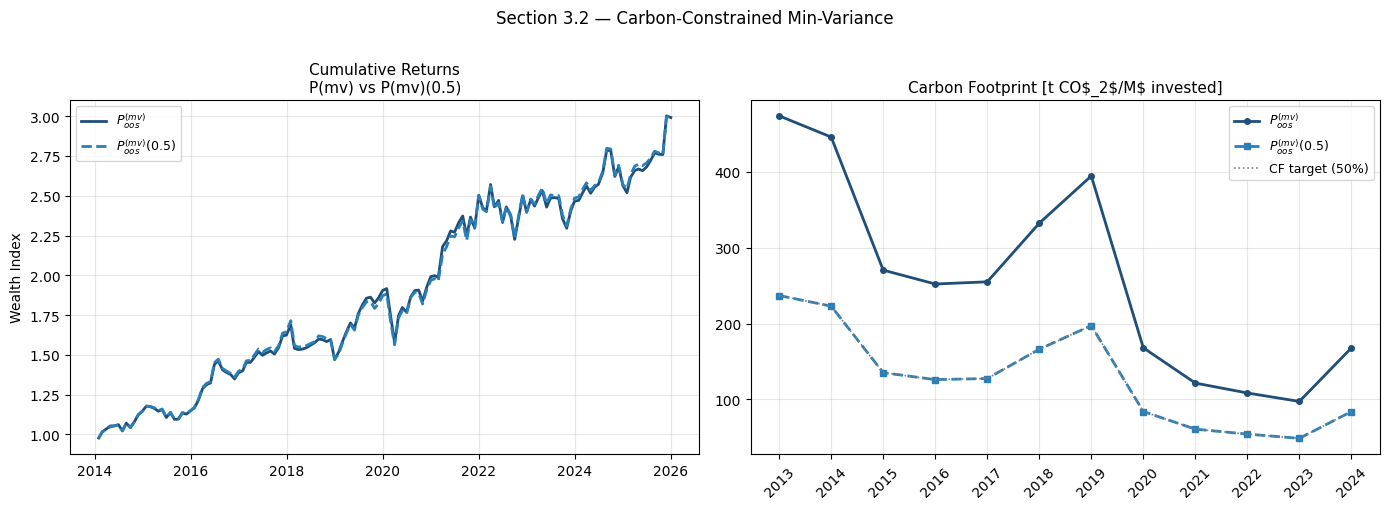

CF reduction vs unconstrained MV:
  2013: CF(mv)=474.01  CF(mv05)=237.00  reduction=50.0%
  2014: CF(mv)=446.04  CF(mv05)=223.02  reduction=50.0%
  2015: CF(mv)=270.51  CF(mv05)=135.26  reduction=50.0%
  2016: CF(mv)=252.22  CF(mv05)=126.11  reduction=50.0%
  2017: CF(mv)=255.10  CF(mv05)=127.55  reduction=50.0%
  2018: CF(mv)=332.41  CF(mv05)=166.20  reduction=50.0%
  2019: CF(mv)=394.74  CF(mv05)=197.37  reduction=50.0%
  2020: CF(mv)=168.09  CF(mv05)=84.05  reduction=50.0%
  2021: CF(mv)=121.54  CF(mv05)=60.77  reduction=50.0%
  2022: CF(mv)=108.47  CF(mv05)=54.24  reduction=50.0%
  2023: CF(mv)=97.32  CF(mv05)=48.66  reduction=50.0%
  2024: CF(mv)=167.89  CF(mv05)=83.94  reduction=50.0%


In [9]:
waci_mv05, cf_mv05 = compute_carbon_metrics_portfolio(
    mv05_weights, investment_sets, co2_total, CI, mv_y, years_alloc
)

cum_mv   = (1 + df_mv_ret['Return']).cumprod()
cum_mv05 = (1 + df_mv05_ret['Return']).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cum_mv.index,   cum_mv.values,   color=COLOR_MV,   lw=2, label=r'$P^{(mv)}_{oos}$')
ax.plot(cum_mv05.index, cum_mv05.values, color=COLOR_MV05, lw=2, ls='--',
        label=r'$P^{(mv)}_{oos}(0.5)$')
ax.set_title('Cumulative Returns\nP(mv) vs P(mv)(0.5)', fontsize=11)
ax.set_ylabel('Wealth Index')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(years_p, [cf_mv[Y]   for Y in years_p], color=COLOR_MV,   lw=2, marker='o', ms=4,
        label=r'$P^{(mv)}_{oos}$')
ax.plot(years_p, [cf_mv05[Y] for Y in years_p], color=COLOR_MV05, lw=2, marker='s', ms=4,
        ls='--', label=r'$P^{(mv)}_{oos}(0.5)$')
ax.plot(years_p, [0.5*cf_mv[Y] for Y in years_p], color='grey', lw=1.2, ls=':',
        label='CF target (50%)')
ax.set_title(r'Carbon Footprint [t CO$_2$/M$ invested]', fontsize=11)
ax.set_xticks(years_p)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle('Section 3.2 — Carbon-Constrained Min-Variance', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}sec32_cumret_cf.png', dpi=150, bbox_inches='tight')
plt.show()

print('CF reduction vs unconstrained MV:')
for Y in years_alloc:
    red = (cf_mv[Y] - cf_mv05[Y]) / cf_mv[Y] * 100
    print(f'  {Y}: CF(mv)={cf_mv[Y]:.2f}  CF(mv05)={cf_mv05[Y]:.2f}  reduction={red:.1f}%')

In [10]:
# Section 3.2 — Portfolio composition analysis
composition_rows = []

for Y in years_alloc:
    isins = investment_sets[Y]

    # Convert Series to dict before the ISIN loop.
    # Series.get() is fragile when the index has duplicates (returns a Series
    # instead of a scalar). Dict.get() is O(1) and always returns a scalar.
    alpha_mv_dict   = mv_weights_dict[Y].reindex(isins).fillna(0.0).to_dict()
    alpha_mv05_dict = mv05_weights[Y].to_dict()
    c_dict          = dict(zip(isins, precomp[Y]['carbon_coeffs']))
    ci_dict         = CI[Y].reindex(isins).to_dict()

    for isin in isins:
        wt_old = alpha_mv_dict.get(isin, 0.0)
        wt_new = alpha_mv05_dict.get(isin, 0.0)
        if wt_old > 1e-8 or wt_new > 1e-8:
            composition_rows.append({
                'Year': Y, 'ISIN': isin,
                'Name': str(firm_names.get(isin, 'N/A'))[:35],
                'wt_mv': wt_old, 'wt_mv05': wt_new,
                'delta_wt': wt_new - wt_old,
                'c_i': c_dict.get(isin, 0.0),
                'CI_i': ci_dict.get(isin, np.nan),
            })

df_comp      = pd.DataFrame(composition_rows)
excluded     = df_comp[(df_comp['wt_mv'] > 1e-8) & (df_comp['wt_mv05'] < 1e-8)]
overweighted = df_comp[df_comp['delta_wt'] > 5e-4]

print(f'Firm-year pairs tracked:   {len(df_comp)}')
print(f'Exclusions (wt drops to 0): {len(excluded)}')
print(f'Over-weighted (delta>0.05%): {len(overweighted)}')

if len(excluded) > 0:
    print('\nTop 10 excluded firms by average carbon coefficient c_i = E/Cap:')
    excl_avg = (
        excluded.groupby(['ISIN', 'Name'])
        .agg(avg_wt_mv=('wt_mv', 'mean'), avg_c=('c_i', 'mean'),
             avg_CI=('CI_i', 'mean'), n_years=('Year', 'count'))
        .reset_index().nlargest(10, 'avg_c')
    )
    print(f'{"ISIN":<15} {"Name":<35} {"avg wt(mv)":>10} {"avg c_i":>10} {"avg CI":>10} {"yrs":>5}')
    print('-' * 90)
    for _, row in excl_avg.iterrows():
        print(f'{row["ISIN"]:<15} {row["Name"]:<35} {row["avg_wt_mv"]:>10.4f} '
              f'{row["avg_c"]:>10.1f} {row["avg_CI"]:>10.1f} {int(row["n_years"]):>5}')

Firm-year pairs tracked:   394
Exclusions (wt drops to 0): 34
Over-weighted (delta>0.05%): 193

Top 10 excluded firms by average carbon coefficient c_i = E/Cap:
ISIN            Name                                avg wt(mv)    avg c_i     avg CI   yrs
------------------------------------------------------------------------------------------
US1252691001    CF INDUSTRIES HDG.                      0.0052     1889.9     4260.6     1
US92939U1060    WEC ENERGY GROUP                        0.0063     1385.2     3543.7     1
US8425871071    SOUTHERN                                0.0155     1263.1     3326.3     4
US69351T1060    PPL                                     0.0049     1200.6     3463.4     1
US26441C2044    DUKE ENERGY                             0.0282     1132.2     3006.9     2
US4198701009    HAWAIIAN ELECTRIC INDS.                 0.0170     1005.8     1432.2     1
US1258961002    CMS ENERGY                              0.0120     1002.7     2278.3     4
US25746U1097    DOMI

---
## Section 3.3 — $P^{(vw)}_{oos}(0.5)$: Tracking-Error Minimization

The CF target ($0.5\times CF^{(vw)}$) is **tighter** than in 3.2 ($0.5\times CF^{(mv)}$)
since $CF^{(vw)} \ll CF^{(mv)}$ throughout the sample.

**Starting point strategy:**
- **Year 2013:** `find_feasible_seed` constructs a blend of $w^{(vw)}$ and the
  minimum-carbon firm that exactly meets cf_target. This is always feasible by construction
  and closer to $w^{(vw)}$ than pure equal-weighting.
- **Years 2014–2024:** warm-start from the previous year's 3.3 solution.



In [11]:
te05_weights      = {}
te05_stats        = []
prev_weights_te05 = None

print(f'{"Year":<6} {"N":>5} {"N_nz":>6} {"max_wt":>8} {"CF_actual":>10} '
      f'{"CF_target":>10} {"CF_ok":>8} {"TE_ann%":>9} {"Conv":>6}')
print('-' * 80)

for Y in years_alloc:
    pc    = precomp[Y]
    isins = pc['isins']
    n     = pc['n']

    # Starting point for 3.3.
    if prev_weights_te05 is not None:
        # Warm-start from previous year (feasible by construction if investment
        # set hasn't changed dramatically; checked below).
        x0 = pd.Series(prev_weights_te05, index=precomp[Y - 1]['isins']) \
               .reindex(isins).fillna(0.0).values
        x0 = x0 / x0.sum() if x0.sum() > 1e-10 else find_feasible_seed(
            pc['carbon_coeffs'], pc['w_vw'],
            pc['cf_vw_actual'], pc['cf_target_te05']
        )
        # Verify warm-start satisfies the CF constraint after re-alignment.
        if float(pc['carbon_coeffs'] @ x0) > pc['cf_target_te05'] * (1 + 1e-6):
            x0 = find_feasible_seed(
                pc['carbon_coeffs'], pc['w_vw'],
                pc['cf_vw_actual'], pc['cf_target_te05']
            )
    else:
        # First year: construct a feasible seed (blend of w_vw and min-c firm).
        x0 = find_feasible_seed(
            pc['carbon_coeffs'], pc['w_vw'],
            pc['cf_vw_actual'], pc['cf_target_te05']
        )

    weights, te_ann, success = solve_te_carbon_constrained(
        pc['cov_matrix'], n, pc['w_vw'],
        pc['carbon_coeffs'], pc['cf_target_te05'], x0
    )
    if not success:
        print(f'  WARNING Year {Y}: optimizer did not converge.')

    te05_weights[Y]   = pd.Series(weights, index=isins)
    prev_weights_te05 = weights.copy()

    # Post-clip CF check.
    cf_actual = float(pc['carbon_coeffs'] @ weights)
    cf_target = pc['cf_target_te05']
    satisfied = cf_actual <= cf_target * (1 + 1e-4)
    if not satisfied:
        print(f'  WARNING Year {Y}: CF constraint violated post-clip '
              f'({cf_actual:.4f} > {cf_target:.4f})')

    n_nz = int((weights > 1e-8).sum())
    te05_stats.append({
        'Year': Y, 'N_firms': n, 'N_nonzero': n_nz,
        'Max_weight': weights.max(), 'CF_actual': cf_actual,
        'CF_target': cf_target, 'CF_satisfied': satisfied,
        'TE_ann': te_ann, 'Converged': success,
    })
    print(f'{Y:<6} {n:>5} {n_nz:>6} {weights.max():>8.4f} {cf_actual:>10.4f} '
          f'{cf_target:>10.4f} {str(satisfied):>8} {te_ann*100:>9.3f} {str(success):>6}')

df_te05_stats = pd.DataFrame(te05_stats).set_index('Year')
n_viol = df_te05_stats['CF_satisfied'].eq(False).sum()
n_fail = df_te05_stats['Converged'].eq(False).sum()
print(f'\nSummary: {n_fail} convergence failures, {n_viol} post-clip CF violations.')
print(f'Average annualized TE: {df_te05_stats["TE_ann"].mean()*100:.3f}%')

Year       N   N_nz   max_wt  CF_actual  CF_target    CF_ok   TE_ann%   Conv
--------------------------------------------------------------------------------
2013     337    260   0.0559    81.1966    81.1966     True     0.042   True
2014     348    293   0.0423    75.7510    75.7510     True     0.044   True
2015     364    318   0.0518    63.9905    63.9905     True     0.042   True
2016     381    322   0.0420    69.0752    69.0752     True     0.042   True
2017     400    345   0.0417    56.4853    56.4853     True     0.040   True
2018     436    380   0.0488    47.4082    47.4082     True     0.031   True
2019     503    420   0.0515    47.7766    47.7766     True     0.035   True
2020     532    434   0.0608    36.3446    36.3446     True     0.035   True
2021     560    448   0.0683    32.9365    32.9365     True     0.028   True
2022     570    452   0.0710    26.8709    26.8709     True     0.026   True
2023     570    446   0.0690    29.1083    29.1083     True     0.029   

In [12]:
df_te05_ret = compute_ex_post_returns(
    te05_weights, investment_sets, returns_m, dates_ret, Y0, Y_END
)
print(f'P(vw)_oos(0.5): {len(df_te05_ret)} months | '
      f'{df_te05_ret.index[0].strftime("%Y-%m")} to '
      f'{df_te05_ret.index[-1].strftime("%Y-%m")}')

P(vw)_oos(0.5): 144 months | 2014-01 to 2025-12


In [13]:
stats_vw   = compute_performance_stats(df_vw_ret,   rf_dict, 'P(vw)')
stats_te05 = compute_performance_stats(df_te05_ret, rf_dict, 'P(vw)_oos(0.5)')

df_stats_33 = pd.DataFrame([stats_vw, stats_te05]).set_index('Portfolio')
print('Performance comparison — Section 3.3:')
print('=' * 65)
for col in ['Ann. Return', 'Ann. Vol.', 'CAGR', 'Sharpe Ratio', 'Min Monthly', 'Max Monthly']:
    row = f'  {col:<22}'
    for p in df_stats_33.index:
        row += f'  {df_stats_33.loc[p, col]:>12.4f}'
    print(row)
print('\nDifference (constrained - unconstrained):')
for col in ['Ann. Return', 'Ann. Vol.', 'Sharpe Ratio']:
    diff = df_stats_33.loc['P(vw)_oos(0.5)', col] - df_stats_33.loc['P(vw)', col]
    print(f'  {col:<24} {diff:+.4f}')

Performance comparison — Section 3.3:
  Ann. Return                   0.1330        0.1248
  Ann. Vol.                     0.1421        0.1460
  CAGR                          0.1301        0.1203
  Sharpe Ratio                  0.8133        0.7356
  Min Monthly                  -0.1219       -0.1399
  Max Monthly                   0.1269        0.1347

Difference (constrained - unconstrained):
  Ann. Return              -0.0082
  Ann. Vol.                +0.0039
  Sharpe Ratio             -0.0777


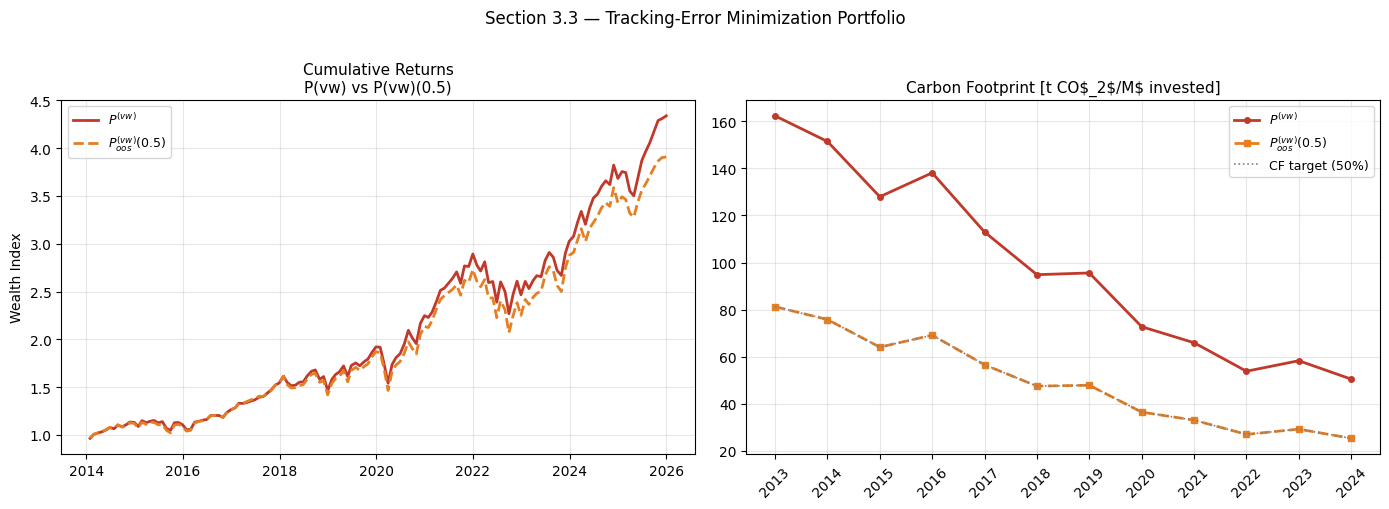

CF reduction vs unconstrained VW:
  2013: CF(vw)=162.393  CF(te05)=81.197  reduction=50.0%
  2014: CF(vw)=151.502  CF(te05)=75.751  reduction=50.0%
  2015: CF(vw)=127.981  CF(te05)=63.990  reduction=50.0%
  2016: CF(vw)=138.150  CF(te05)=69.075  reduction=50.0%
  2017: CF(vw)=112.971  CF(te05)=56.485  reduction=50.0%
  2018: CF(vw)=94.816  CF(te05)=47.408  reduction=50.0%
  2019: CF(vw)=95.553  CF(te05)=47.777  reduction=50.0%
  2020: CF(vw)=72.689  CF(te05)=36.345  reduction=50.0%
  2021: CF(vw)=65.873  CF(te05)=32.937  reduction=50.0%
  2022: CF(vw)=53.742  CF(te05)=26.871  reduction=50.0%
  2023: CF(vw)=58.217  CF(te05)=29.108  reduction=50.0%
  2024: CF(vw)=50.389  CF(te05)=25.194  reduction=50.0%


In [14]:
waci_te05, cf_te05 = compute_carbon_metrics_portfolio(
    te05_weights, investment_sets, co2_total, CI, mv_y, years_alloc
)

cum_vw   = (1 + df_vw_ret['Return']).cumprod()
cum_te05 = (1 + df_te05_ret['Return']).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cum_vw.index,   cum_vw.values,   color=COLOR_VW,   lw=2, label=r'$P^{(vw)}$')
ax.plot(cum_te05.index, cum_te05.values, color=COLOR_TE05, lw=2, ls='--',
        label=r'$P^{(vw)}_{oos}(0.5)$')
ax.set_title('Cumulative Returns\nP(vw) vs P(vw)(0.5)', fontsize=11)
ax.set_ylabel('Wealth Index')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(years_p, [cf_vw[Y]   for Y in years_p], color=COLOR_VW,   lw=2, marker='o', ms=4,
        label=r'$P^{(vw)}$')
ax.plot(years_p, [cf_te05[Y] for Y in years_p], color=COLOR_TE05, lw=2, marker='s', ms=4,
        ls='--', label=r'$P^{(vw)}_{oos}(0.5)$')
ax.plot(years_p, [0.5*cf_vw[Y] for Y in years_p], color='grey', lw=1.2, ls=':',
        label='CF target (50%)')
ax.set_title(r'Carbon Footprint [t CO$_2$/M$ invested]', fontsize=11)
ax.set_xticks(years_p)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle('Section 3.3 — Tracking-Error Minimization Portfolio', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}sec33_cumret_cf.png', dpi=150, bbox_inches='tight')
plt.show()

print('CF reduction vs unconstrained VW:')
for Y in years_alloc:
    red = (cf_vw[Y] - cf_te05[Y]) / cf_vw[Y] * 100
    print(f'  {Y}: CF(vw)={cf_vw[Y]:.3f}  CF(te05)={cf_te05[Y]:.3f}  reduction={red:.1f}%')

---
## Section 3.4 — Comparison of Portfolios

In [15]:
all_stats = pd.DataFrame([stats_mv, stats_mv05, stats_vw, stats_te05]).set_index('Portfolio')

display_stats = all_stats[['Ann. Return','Ann. Vol.','CAGR',
                            'Sharpe Ratio','Min Monthly','Max Monthly']].copy()
for c in ['Ann. Return','Ann. Vol.','CAGR','Min Monthly','Max Monthly']:
    display_stats[c] = display_stats[c].map(lambda x: f'{x*100:.2f}%')
display_stats['Sharpe Ratio'] = display_stats['Sharpe Ratio'].map(lambda x: f'{x:.4f}')

print('All-portfolio performance summary (2014-2025):')
display(display_stats)

# CF_mean: simple average across allocation years (equal weight per year).
cf_summary = pd.DataFrame({
    'CF_mean'  : {k: np.mean(list(v.values())) for k, v in
                  [('P(mv)_oos',cf_mv),('P(mv)_oos(0.5)',cf_mv05),
                   ('P(vw)',cf_vw),('P(vw)_oos(0.5)',cf_te05)]},
    'WACI_mean': {k: np.mean(list(v.values())) for k, v in
                  [('P(mv)_oos',waci_mv),('P(mv)_oos(0.5)',waci_mv05),
                   ('P(vw)',waci_vw),('P(vw)_oos(0.5)',waci_te05)]},
    'CF_2013'  : {'P(mv)_oos':cf_mv[2013],'P(mv)_oos(0.5)':cf_mv05[2013],
                  'P(vw)':cf_vw[2013],'P(vw)_oos(0.5)':cf_te05[2013]},
    'CF_2024'  : {'P(mv)_oos':cf_mv[2024],'P(mv)_oos(0.5)':cf_mv05[2024],
                  'P(vw)':cf_vw[2024],'P(vw)_oos(0.5)':cf_te05[2024]},
})
print('\nCarbon metrics summary:')
display(cf_summary.round(3))

All-portfolio performance summary (2014-2025):


,Ann. Return,Ann. Vol.,CAGR,Sharpe Ratio,Min Monthly,Max Monthly
Portfolio,,,,,,
P(mv)_oos,9.92%,12.32%,9.56%,0.6639,-10.08%,10.80%
P(mv)_oos(0.5),9.93%,12.18%,9.58%,0.6716,-9.12%,10.87%
P(vw),13.30%,14.21%,13.01%,0.8133,-12.19%,12.69%
P(vw)_oos(0.5),12.48%,14.60%,12.03%,0.7356,-13.99%,13.47%



Carbon metrics summary:


,CF_mean,WACI_mean,CF_2013,CF_2024
P(mv)_oos,257.363,526.061,474.010,167.887
P(mv)_oos(0.5),128.681,232.848,237.005,83.943
P(vw),98.690,189.923,162.393,50.389
P(vw)_oos(0.5),49.345,94.802,81.197,25.194


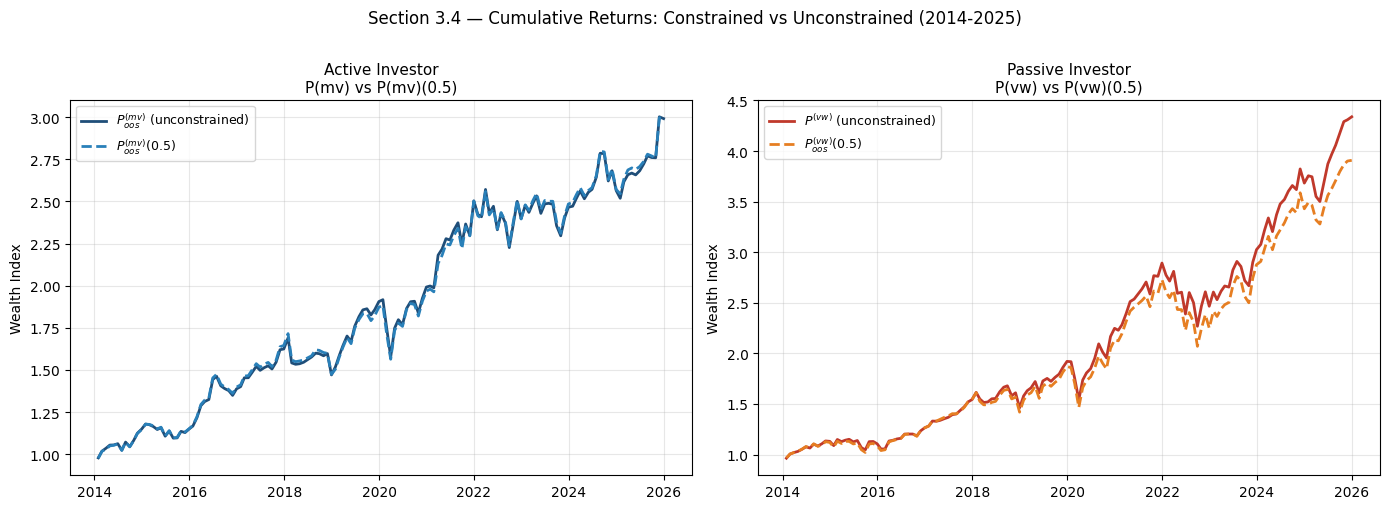

In [16]:
# cum_mv05 and cum_vw are NOT redefined here; they were computed
# in the Section 3.2 and 3.3 plotting cells respectively.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cum_mv.index,   cum_mv.values,   color=COLOR_MV,   lw=2,
        label=r'$P^{(mv)}_{oos}$ (unconstrained)')
ax.plot(cum_mv05.index, cum_mv05.values, color=COLOR_MV05, lw=2, ls='--',
        label=r'$P^{(mv)}_{oos}(0.5)$')
ax.set_title('Active Investor\nP(mv) vs P(mv)(0.5)', fontsize=11)
ax.set_ylabel('Wealth Index')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(cum_vw.index,   cum_vw.values,   color=COLOR_VW,   lw=2,
        label=r'$P^{(vw)}$ (unconstrained)')
ax.plot(cum_te05.index, cum_te05.values, color=COLOR_TE05, lw=2, ls='--',
        label=r'$P^{(vw)}_{oos}(0.5)$')
ax.set_title('Passive Investor\nP(vw) vs P(vw)(0.5)', fontsize=11)
ax.set_ylabel('Wealth Index')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle('Section 3.4 — Cumulative Returns: Constrained vs Unconstrained (2014-2025)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}sec34_cumret_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

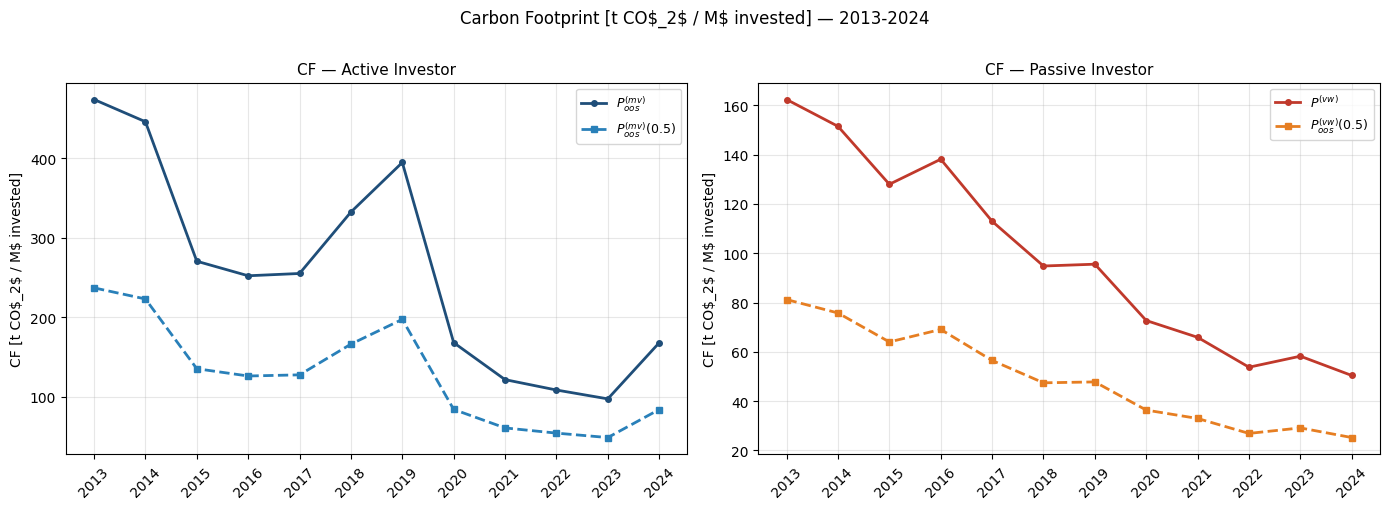

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(years_p,[cf_mv[Y]   for Y in years_p],color=COLOR_MV,  lw=2,marker='o',ms=4,label=r'$P^{(mv)}_{oos}$')
ax.plot(years_p,[cf_mv05[Y] for Y in years_p],color=COLOR_MV05,lw=2,marker='s',ms=4,ls='--',label=r'$P^{(mv)}_{oos}(0.5)$')
ax.set_title(r'CF — Active Investor',fontsize=11)
ax.set_ylabel(r'CF [t CO$_2$ / M$ invested]')
ax.set_xticks(years_p); ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax = axes[1]
ax.plot(years_p,[cf_vw[Y]   for Y in years_p],color=COLOR_VW,  lw=2,marker='o',ms=4,label=r'$P^{(vw)}$')
ax.plot(years_p,[cf_te05[Y] for Y in years_p],color=COLOR_TE05,lw=2,marker='s',ms=4,ls='--',label=r'$P^{(vw)}_{oos}(0.5)$')
ax.set_title(r'CF — Passive Investor',fontsize=11)
ax.set_ylabel(r'CF [t CO$_2$ / M$ invested]')
ax.set_xticks(years_p); ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

fig.suptitle(r'Carbon Footprint [t CO$_2$ / M$ invested] — 2013-2024',fontsize=12,y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}sec34_cf_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

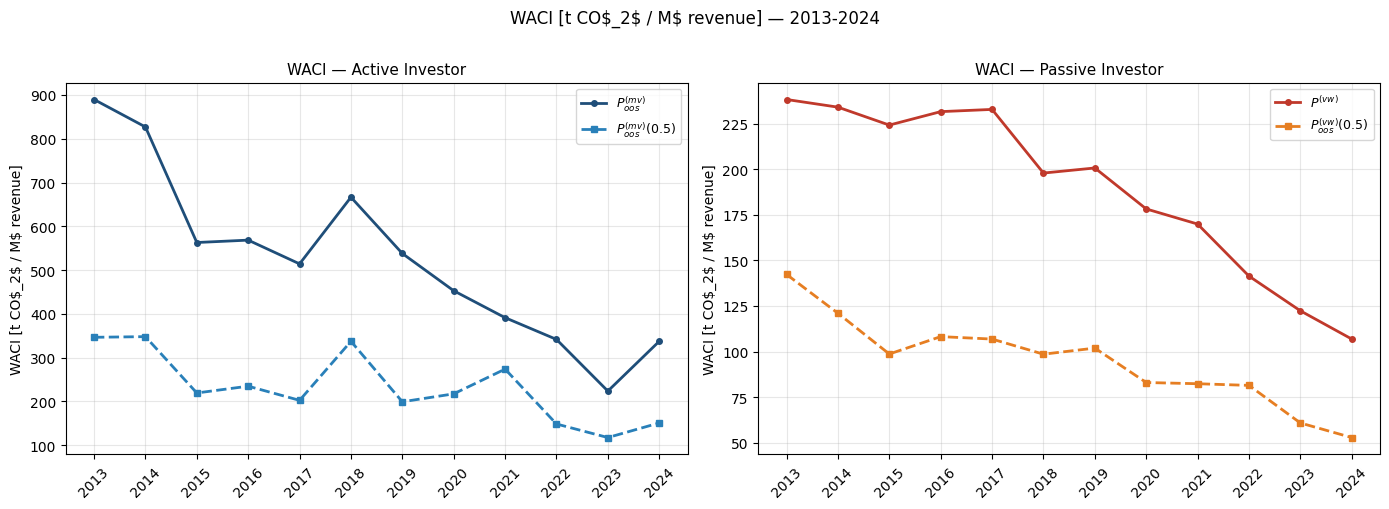

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(years_p,[waci_mv[Y]   for Y in years_p],color=COLOR_MV,  lw=2,marker='o',ms=4,label=r'$P^{(mv)}_{oos}$')
ax.plot(years_p,[waci_mv05[Y] for Y in years_p],color=COLOR_MV05,lw=2,marker='s',ms=4,ls='--',label=r'$P^{(mv)}_{oos}(0.5)$')
ax.set_title('WACI — Active Investor',fontsize=11)
ax.set_ylabel(r'WACI [t CO$_2$ / M$ revenue]')
ax.set_xticks(years_p); ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax = axes[1]
ax.plot(years_p,[waci_vw[Y]   for Y in years_p],color=COLOR_VW,  lw=2,marker='o',ms=4,label=r'$P^{(vw)}$')
ax.plot(years_p,[waci_te05[Y] for Y in years_p],color=COLOR_TE05,lw=2,marker='s',ms=4,ls='--',label=r'$P^{(vw)}_{oos}(0.5)$')
ax.set_title('WACI — Passive Investor',fontsize=11)
ax.set_ylabel(r'WACI [t CO$_2$ / M$ revenue]')
ax.set_xticks(years_p); ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

fig.suptitle(r'WACI [t CO$_2$ / M$ revenue] — 2013-2024',fontsize=12,y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}sec34_waci_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

In [19]:
tradeoff = {
    'Active investor (MV pair)': {
        'CF reduction (%)' : (1 - np.mean(list(cf_mv05.values())) /
                                  np.mean(list(cf_mv.values()))) * 100,
        'Sharpe difference': stats_mv05['Sharpe Ratio'] - stats_mv['Sharpe Ratio'],
        'Return difference': stats_mv05['Ann. Return']  - stats_mv['Ann. Return'],
        'Vol difference'   : stats_mv05['Ann. Vol.']    - stats_mv['Ann. Vol.'],
    },
    'Passive investor (VW pair)': {
        'CF reduction (%)' : (1 - np.mean(list(cf_te05.values())) /
                                  np.mean(list(cf_vw.values()))) * 100,
        'Sharpe difference': stats_te05['Sharpe Ratio'] - stats_vw['Sharpe Ratio'],
        'Return difference': stats_te05['Ann. Return']  - stats_vw['Ann. Return'],
        'Vol difference'   : stats_te05['Ann. Vol.']    - stats_vw['Ann. Vol.'],
    },
}
df_tradeoff = pd.DataFrame(tradeoff).T
print('Trade-off: carbon reduction vs financial cost')
print('=' * 72)
print(f'{"":30} {"CF reduc.%":>12} {"Sharpe diff":>13} {"Return diff":>13} {"Vol diff":>10}')
print('-' * 72)
for idx, row in df_tradeoff.iterrows():
    print(f'{idx:<30} {row["CF reduction (%)"]:>12.1f} '
          f'{row["Sharpe difference"]:>+13.4f} '
          f'{row["Return difference"]*100:>+12.2f}% '
          f'{row["Vol difference"]*100:>+9.2f}%')

Trade-off: carbon reduction vs financial cost
                                 CF reduc.%   Sharpe diff   Return diff   Vol diff
------------------------------------------------------------------------
Active investor (MV pair)              50.0       +0.0077        +0.00%     -0.14%
Passive investor (VW pair)             50.0       -0.0777        -0.82%     +0.39%


## 5. Save Results

In [20]:
df_mv05_ret.to_csv(f'{DATA_DIR}mv05_portfolio_returns.csv')
df_te05_ret.to_csv(f'{DATA_DIR}te05_portfolio_returns.csv')

def save_weights(wt_dict, filename):
    rows = []
    for Y, w in wt_dict.items():
        for isin, wt in w.items():
            if wt > 1e-10:
                rows.append({'Year': Y, 'ISIN': isin, 'Weight': wt})
    pd.DataFrame(rows).to_csv(f'{DATA_DIR}{filename}', index=False)

save_weights(mv05_weights, 'mv05_optimal_weights.csv')
save_weights(te05_weights, 'te05_optimal_weights.csv')

pd.DataFrame({'CF_mv05': cf_mv05, 'CF_te05': cf_te05,
              'WACI_mv05': waci_mv05, 'WACI_te05': waci_te05}).to_csv(
    f'{DATA_DIR}carbon_metrics_constrained.csv'
)
all_stats.to_csv(f'{DATA_DIR}summary_stats_sec32_33.csv')
df_mv05_stats.to_csv(f'{DATA_DIR}mv05_opt_diagnostics.csv')
df_te05_stats.to_csv(f'{DATA_DIR}te05_opt_diagnostics.csv')

saved = ['mv05_portfolio_returns.csv','te05_portfolio_returns.csv',
         'mv05_optimal_weights.csv','te05_optimal_weights.csv',
         'carbon_metrics_constrained.csv','summary_stats_sec32_33.csv',
         'mv05_opt_diagnostics.csv','te05_opt_diagnostics.csv']
print('Saved to cleaned_data/:')
for f in saved:
    kb = os.path.getsize(f'{DATA_DIR}{f}') / 1024
    print(f'  {f:<45} {kb:>7.1f} KB')
print(f'\nCharts saved to {CHARTS_DIR}:')
for f in ['sec32_cumret_cf.png','sec33_cumret_cf.png',
          'sec34_cumret_comparison.png','sec34_cf_comparison.png',
          'sec34_waci_comparison.png']:
    if os.path.exists(f'{CHARTS_DIR}{f}'):
        print(f'  {f}')
print('\nNext step: Section 4.1 - Net-Zero Portfolio.')

Saved to cleaned_data/:
  mv05_portfolio_returns.csv                        4.7 KB
  te05_portfolio_returns.csv                        4.6 KB
  mv05_optimal_weights.csv                         13.9 KB
  te05_optimal_weights.csv                        183.1 KB
  carbon_metrics_constrained.csv                    1.0 KB
  summary_stats_sec32_33.csv                        0.7 KB
  mv05_opt_diagnostics.csv                          1.3 KB
  te05_opt_diagnostics.csv                          1.3 KB

Charts saved to ./Charts/:
  sec32_cumret_cf.png
  sec33_cumret_cf.png
  sec34_cumret_comparison.png
  sec34_cf_comparison.png
  sec34_waci_comparison.png

Next step: Section 4.1 - Net-Zero Portfolio.
